# ONLINE LEARNING APPLICATIONS - Course Project

## Riccardo Piantoni

### A.Y. 2025/2026

In [127]:
%load_ext autoreload
%autoreload 2

import numpy as np

import matplotlib.pyplot as plt

#from advertising_market_simulator import AdvertisementMarketSimulator
from environment.environment import Environment
from experiment import Experiment
from campaigns.uniform_bids_stochastic_campaign import UniformBidsStochasticCampaign
from bidders.UCB_based.ucb_like_bidder import UCBLikeBidder

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Requirement 1: Single campaign and stochastic environment

### Environment

Build a stochastic environment:
- A distribution over the highest competing bid

Modeling assumptions: the highest competing bid for a single campaign follows a Beta distribution if the single bids are Gaussian (we can assume they are in a single-campaign setting)

Questions:
- Must we use Beta(n, 1), or can we also use other parameters? What do they correspond to in a real market?
- Is a Uniform distribution the best assumption for stochastic single bids?

In [128]:
N_TRIALS = 2  # trials for proper curve estimation

BIDS_SPACE = np.linspace(0.0, 1.0, 11)  # possible bids = action space of size 10

# market = AdvertisementMarketSimulator()
environment = Environment(BIDS_SPACE)
environment.generate_random_campaigns(n_campaigns=1, campaign_type=UniformBidsStochasticCampaign, min_competitors=1, max_competitors=3, conflicts_percentage=0.0, seed=47)  # generate a single campaign with random qualities for each advertisers
print(environment)

N_USERS = 1000  # number of ads to be shown sequentially = n_rounds = T

RHO = 0.075  # budget per round -> define either rho or the starting budget B and derive the other (rho = B/T)

-- ENVIRONMENT: --
Bids space: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Number of campaigns: 1
Campaigns:
    -- CAMPAIGN: --
    Type: Uniform Bids
    Description: Competing bids sampled from a stochastic uniform distribution, maximum bid follows a Beta distribution.
    Ad qualities: [1. 1. 1. 1.]
    Number of advertisers: 4
    Number of competitors: 3
Conflicts graph matrix (1 = conflicting):
[[0]]


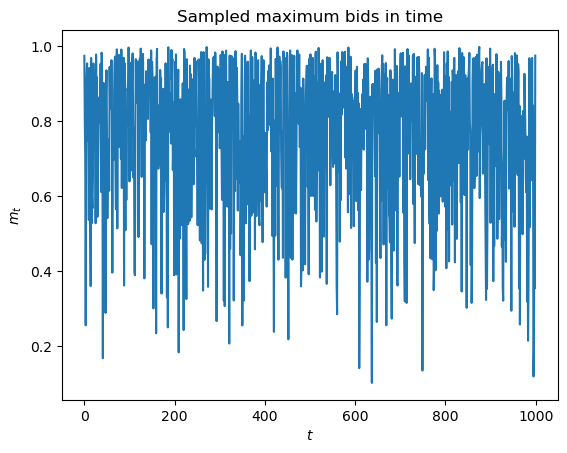

In [129]:
for campaign in environment.campaigns:
    campaign.generate_random_competing_bids(n_users=N_USERS, seed=47)  # generate random competing bids for each advertiser in the campaign
    campaign.plot_max_competing_bids()

### Design algorithms for a single campaign and stochastic environment
- Build a bidding strategy using UCB1 ignoring the budget constraint.
- Build a bidding strategy extending UCB1 to handle the budget constraint

Assumptions: just like in the notebooks

Clairvoyant - combinatorial over campaigns - simple version
campaign_phase_change_times: [array([0], dtype=int64)]
joined_phase_change_times: [0]
joined_indices: [array([0], dtype=int64)]
campaign_gamma_values: [array([[ 0.,  0.,  0.,  0., -0.,  1.,  0.,  0.]])]
Clairvoyant - combinatorial over campaigns - simple version
campaign_phase_change_times: [array([0], dtype=int64)]
joined_phase_change_times: [0]
joined_indices: [array([0], dtype=int64)]
campaign_gamma_values: [array([[ 0.,  0.,  0.,  0., -0.,  1.,  0.,  0.]])]


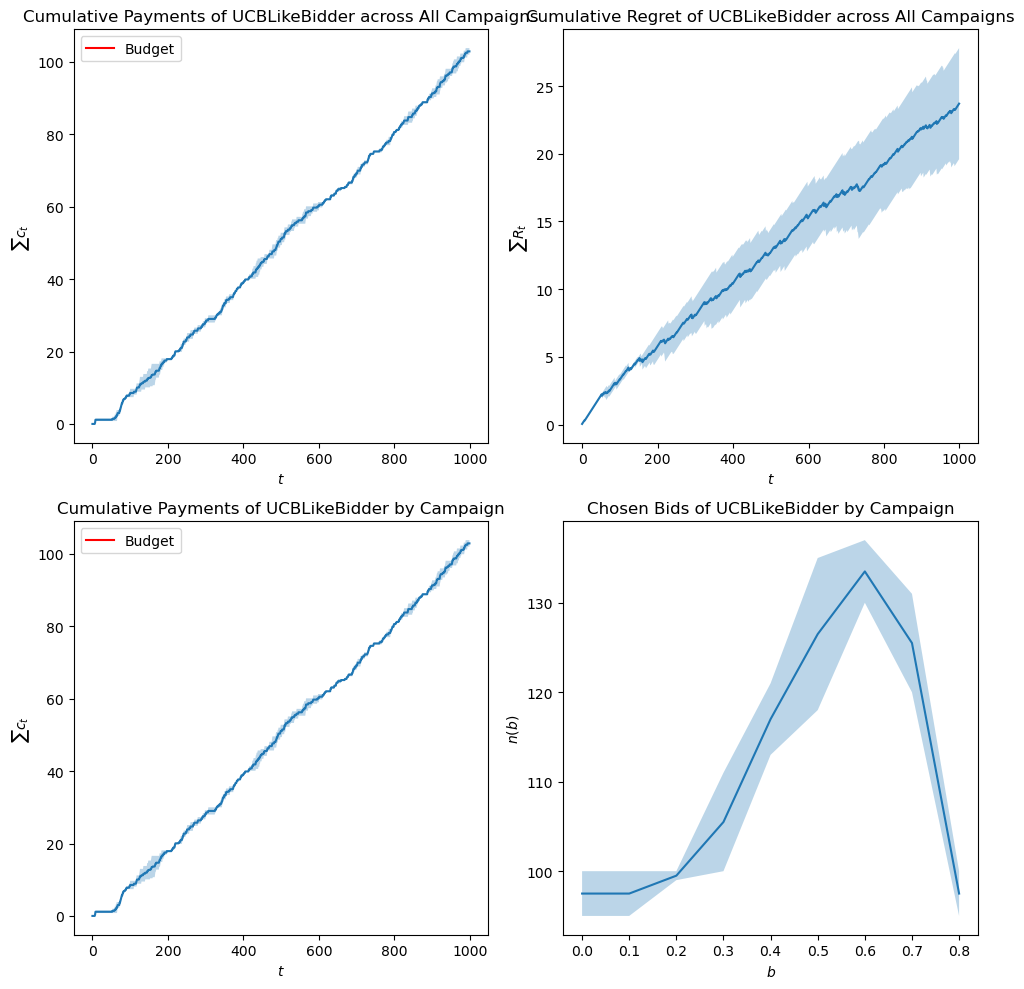

In [130]:
STARTING_BUDGET = np.inf #RHO * N_USERS     # or np.inf for no budget

MY_VALUATION = 0.8  # my true valuation of the ads (assumed to be known)

no_budget_single_campaign_UCB_like_experiment = Experiment(environment=environment,
                                                          bidder_class=UCBLikeBidder, 
                                                          bidder_parameters={
                                                              'B': STARTING_BUDGET, 
                                                              'T': N_USERS, 
                                                              'valuations': [MY_VALUATION for _ in range(environment.N_CAMPAIGNS)], 
                                                              'environment': environment
                                                            })

no_budget_single_campaign_UCB_like_experiment.run_trials(n_trials=N_TRIALS, clairvoyant_strategy_type='simple')

Clairvoyant - combinatorial over campaigns - simple version
campaign_phase_change_times: [array([0], dtype=int64)]
joined_phase_change_times: [0]
joined_indices: [array([0], dtype=int64)]
campaign_gamma_values: [array([[0.        , 0.        , 0.        , 0.        , 0.81371088,
        0.18628912, 0.        , 0.        ]])]
Clairvoyant - combinatorial over campaigns - simple version
campaign_phase_change_times: [array([0], dtype=int64)]
joined_phase_change_times: [0]
joined_indices: [array([0], dtype=int64)]
campaign_gamma_values: [array([[0.        , 0.        , 0.        , 0.        , 0.81371088,
        0.18628912, 0.        , 0.        ]])]


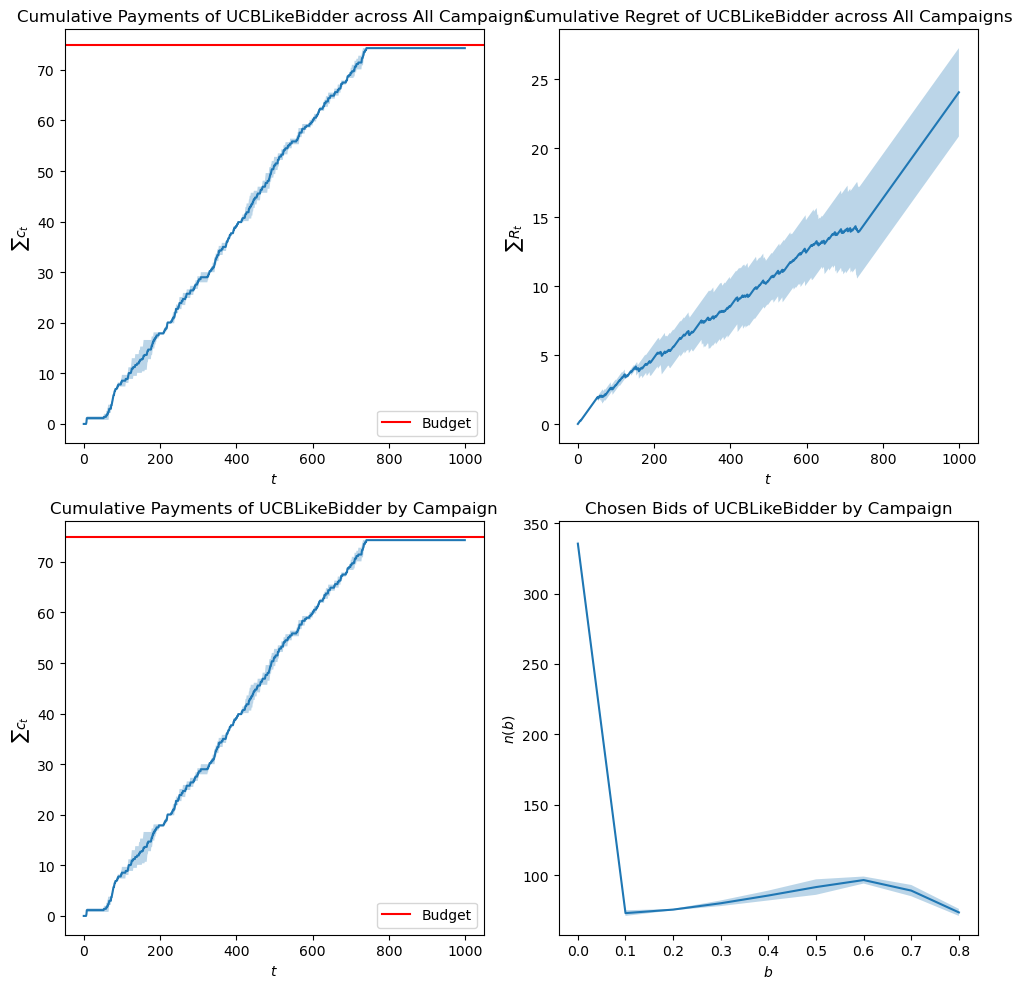

In [131]:
STARTING_BUDGET = RHO * N_USERS     # or np.inf for no budget

MY_VALUATION = 0.8  # my true valuation of the ads (assumed to be known)

budget_constrained_single_campaign_UCB_like_experiment = Experiment(environment=environment,
                                                          bidder_class=UCBLikeBidder, 
                                                          bidder_parameters={
                                                              'B': STARTING_BUDGET, 
                                                              'T': N_USERS, 
                                                              'valuations': [MY_VALUATION for _ in range(environment.N_CAMPAIGNS)], 
                                                              'environment': environment
                                                            })

budget_constrained_single_campaign_UCB_like_experiment.run_trials(n_trials=N_TRIALS, clairvoyant_strategy_type='simple')

# CAPIRE PERCHE' CONTINUA AD ESPLORARE ANCHE TUTTE LE ALTRE BID